In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image
import pandas as pd

def load_images_from_folder(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((256, 256))
                img_array = np.array(img)
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(images), np.array(labels)

# Paths to your dataset folders
benign = 'Dataset/train/colon_n'
malignant = 'Dataset/train/colon_aca'

# Load images and labels
ben_images, ben_labels = load_images_from_folder(benign, label=0)
mal_images, mal_labels = load_images_from_folder(malignant, label=1)

# Combine benign and malignant images
images = np.concatenate((ben_images, mal_images), axis=0)
labels = np.concatenate((ben_labels, mal_labels), axis=0)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# Function to save images to a directory
def save_images_to_folder(images, labels, folder):
    os.makedirs(folder, exist_ok=True)
    for i, (img, label) in enumerate(zip(images, labels)):
        img_folder = os.path.join(folder, 'colon_n' if label == 0 else 'colon_aca')
        os.makedirs(img_folder, exist_ok=True)
        img_pil = Image.fromarray(img)
        img_pil.save(os.path.join(img_folder, f'image_{i}.png'))

# Paths to save the split datasets
train_folder = 'Dataset/train'
test_folder = 'Dataset/test'

# Save the training and testing images
save_images_to_folder(X_train, y_train, train_folder)
save_images_to_folder(X_test, y_test, test_folder)

print("Train-test split and save completed successfully.")

Train-test split and save completed successfully.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import pathlib
import os
import pandas as pd

In [4]:
train_dir = 'Dataset/train'
test_dir = 'Dataset/test'

In [5]:
categories = os.listdir(train_dir)
# Number of images for each disease
nums = {}
for lebal in categories:
    nums[lebal] = len(os.listdir(train_dir + '/' + lebal))

# converting the nums dictionary to pandas dataframe passing index as plant name and number of images as column

img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
colon_aca,9000
colon_n,9000


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout, Layer
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Set image size and batch size
img_height, img_width = 128, 128
batch_size = 32

# Load the training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'  # binary classification
)

# Load the validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical'  # binary classification
)

# Prefetch data for improved performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Define the Squeeze-and-Excitation Layer
class SqueezeExciteLayer(Layer):
    def __init__(self, ratio=16, **kwargs):
        super(SqueezeExciteLayer, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        self.global_avg_pool = GlobalAveragePooling2D()
        self.dense1 = Dense(input_shape[-1] // self.ratio, activation='relu', use_bias=False)
        self.dense2 = Dense(input_shape[-1], activation='sigmoid', use_bias=False)
        super(SqueezeExciteLayer, self).build(input_shape)

    def call(self, inputs):
        x = self.global_avg_pool(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = tf.keras.layers.Reshape((1, 1, inputs.shape[-1]))(x)
        return inputs * x

# Load the base model (ResNet50)
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3)
)

# Freeze the base model layers
base_model.trainable = False

# Build the model
model = Sequential([
    base_model,
    SqueezeExciteLayer(ratio=16),  # Add the Squeeze-and-Excitation layer
    GlobalAveragePooling2D(),      # Add Global Average Pooling
    Dropout(0.3),                  # Add dropout for regularization
    Dense(384, activation='relu'), # Fully connected layer
    Dropout(0.4),                  # Add another dropout
    Dense(2, activation='sigmoid') # Binary classification output with sigmoid
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Found 18000 files belonging to 2 classes.
Using 14400 files for training.
Found 18000 files belonging to 2 classes.
Using 3600 files for validation.


In [39]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 4, 4, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ squeeze_excite_layer_1               │ (None, 4, 4, 2048)          │         524,288 │
│ (SqueezeExciteLayer)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 384)                 │         786,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             770 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,523,336 (104.99 MB)

 Trainable params: 1,311,874 (5.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 2,623,750 (10.01 MB)

None


In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow as tf
import matplotlib.pyplot as plt

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor="val_loss", patience=5, verbose=1, restore_best_weights=True),
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 343s 752ms/step - accuracy: 0.9465 - loss: 0.1372 - val_accuracy: 0.9961 - val_loss: 0.0117 - learning_rate: 3.0000e-04
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 360s 800ms/step - accuracy: 0.9955 - loss: 0.0185 - val_accuracy: 0.9928 - val_loss: 0.0162 - learning_rate: 3.0000e-04
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 335s 745ms/step - accuracy: 0.9961 - loss: 0.0089 - val_accuracy: 0.9994 - val_loss: 0.0022 - learning_rate: 3.0000e-04
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 322s 716ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9986 - val_loss: 0.0040 - learning_rate: 3.0000e-04
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 321s 713ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9967 - val_loss: 0.0078 - learning_rate: 3.0000e-04
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.9990 - loss: 0.0033
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
450/450 ━━━━━━━━━━━━━━━━━━━━ 311s 69

113/113 ━━━━━━━━━━━━━━━━━━━━ 56s 490ms/step
Classification Report:
               precision    recall  f1-score   support

   colon_aca       0.51      0.51      0.51      1819
     colon_n       0.50      0.50      0.50      1781

    accuracy                           0.51      3600
   macro avg       0.51      0.51      0.51      3600
weighted avg       0.51      0.51      0.51      3600



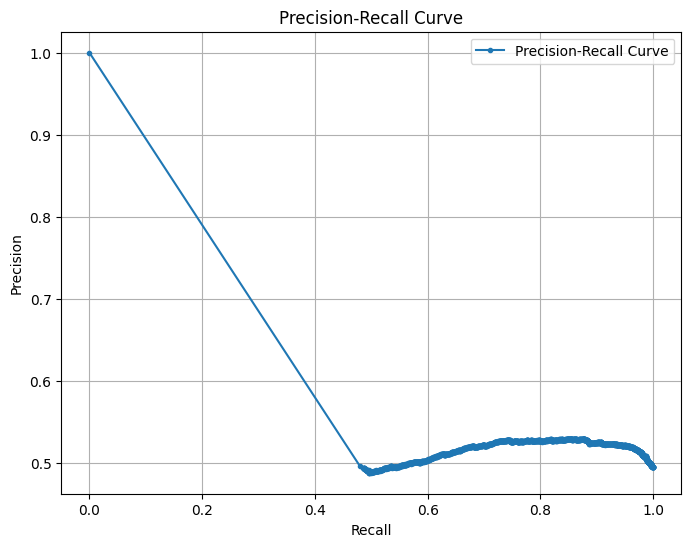

F1-Score: 0.5072222222222222
Accuracy: 0.5072222222222222


In [15]:
import numpy as np
from sklearn.metrics import classification_report, precision_recall_curve, f1_score, accuracy_score
import matplotlib.pyplot as plt

# Manually define class names
class_names = ['colon_aca', 'colon_n']

# Generate predictions for validation set
y_pred_prob = model.predict(val_ds)
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class indices

# Extract true labels and convert to class indices
y_true = np.argmax(np.concatenate([y for _, y in val_ds], axis=0), axis=1)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

# Precision-recall curve
precision, recall, _ = precision_recall_curve(
    y_true,
    y_pred_prob[np.arange(len(y_true)), y_true]  # Probabilities for true classes
)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# F1-Score
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1-Score: {f1}")

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")

In [17]:
model.save('resnetse.keras')